# rMATS result visualization for TGEV

This notebook loads rMATS JCEC outputs, computes summaries, visualizes event counts and significance, and exports significant events.

- Input directory: `/path/to/rMATS/output`
- Event types: `SE`, `RI`, `MXE`, `A3SS`, `A5SS`
- Significance: FDR < 0.05 and |IncLevelDifference| >= 0.1


In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("/path/to/rMATS/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # create if not exist

EVENTS = ["SE", "RI", "MXE", "A3SS", "A5SS"]

FDR_THRESH = 0.05           # False discovery rate cutoff
INC_DIFF_THRESH = 0.1        # Inclusion level (ΔPSI) cutoff

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=1.1,
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "legend.frameon": False,
        "figure.dpi": 150,
    },
)

plt.rcParams.update({
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.figsize": (7, 5),
})

print(f"[rMATS config loaded]")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Event types: {', '.join(EVENTS)}")
print(f"FDR threshold: {FDR_THRESH}")
print(f"Inclusion difference threshold: {INC_DIFF_THRESH}")



[rMATS config loaded]
Output directory: /path/to/rMATS/output
Event types: SE, RI, MXE, A3SS, A5SS
FDR threshold: 0.05
Inclusion difference threshold: 0.1


In [17]:

def compute_summary(all_events: dict, fdr_thresh: float, inc_diff_thresh: float) -> pd.DataFrame:
    rows = []
    for ev, df in all_events.items():
        total = len(df)
        sig_mask = (df['FDR'] < fdr_thresh) & (df['IncLevelDifference'].abs() >= inc_diff_thresh)
        up_mask = (df['FDR'] < fdr_thresh) & (df['IncLevelDifference'] >= inc_diff_thresh)
        down_mask = (df['FDR'] < fdr_thresh) & (df['IncLevelDifference'] <= -inc_diff_thresh)
        genes = df.loc[sig_mask, 'geneSymbol'].dropna().unique()
        rows.append({
            'event_type': ev,
            'total': int(total),
            'sig': int(sig_mask.sum()),
            'up': int(up_mask.sum()),
            'down': int(down_mask.sum()),
            'genes': int(len(genes)),
        })
    return pd.DataFrame(rows)


def plot_total_vs_sig(summary_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df = summary_df.melt(id_vars='event_type', value_vars=['total', 'sig'], var_name='metric', value_name='count')
    sns.barplot(data=plot_df, x='event_type', y='count', hue='metric', ax=ax)
    ax.set_xlabel('Event type')
    ax.set_ylabel('Count')
    ax.set_title('rMATS JCEC: total vs significant events')
    ax.legend(title='')
    plt.tight_layout()


def compute_direction_counts(all_events: dict, fdr_thresh: float, inc_diff_thresh: float) -> pd.DataFrame:
    rows = []
    for ev, df in all_events.items():
        sig = df[(df['FDR'] < fdr_thresh) & (df['IncLevelDifference'].abs() >= inc_diff_thresh)]
        counts = sig['direction'].value_counts().reindex(['Up', 'Down'], fill_value=0)
        rows.append({'event_type': ev, 'Up': int(counts['Up']), 'Down': int(counts['Down'])})
    wide = pd.DataFrame(rows)
    return wide.melt(id_vars='event_type', value_vars=['Up', 'Down'], var_name='direction', value_name='count')


def plot_direction_counts(plot_dir_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=plot_dir_df, x='event_type', y='count', hue='direction', ax=ax)
    ax.set_xlabel('Event type')
    ax.set_ylabel('Significant events')
    ax.set_title('Direction of significant events per type')
    ax.legend(title='')
    plt.tight_layout()


def plot_inc_distribution(combined_df: pd.DataFrame, inc_diff_thresh: float) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.kdeplot(data=combined_df, x='IncLevelDifference', hue='event_type', common_norm=False, ax=ax)
    ax.axvline(inc_diff_thresh, color='k', ls='--', lw=1)
    ax.axvline(-inc_diff_thresh, color='k', ls='--', lw=1)
    ax.set_title('Distribution of IncLevelDifference by event type')
    plt.tight_layout()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_volcano_panels(all_events: dict, fdr_thresh: float, inc_diff_thresh: float, top_n: int = 1, rank_by: str = 'FDR', annotate: bool = True) -> None:
    
    for ev in all_events.keys():
        fig, ax = plt.subplots(figsize=(6, 5)) 
        
        df = all_events[ev].copy()
        df['neglog10FDR'] = -np.log10(df['FDR'].replace(0, np.nan))
        if 'absInc' not in df:
            df['absInc'] = df['IncLevelDifference'].abs()
        
        sns.scatterplot(data=df, x='IncLevelDifference', y='neglog10FDR', hue='is_sig', alpha=0.5, s=10, ax=ax, legend=False)
        
        rank_key = 'FDR' if str(rank_by).lower() == 'fdr' else 'absInc'
        if rank_key == 'FDR':
            top_df = df.sort_values('FDR', na_position='last').head(max(10, int(top_n)))
        else:
            top_df = df.sort_values('absInc', ascending=False).head(max(10, int(top_n)))
            
        ax.scatter(top_df['IncLevelDifference'], top_df['neglog10FDR'], s=60, c='#d62728', edgecolors='black', linewidths=0.6, zorder=3)
        
        if annotate:
            for idx, r in top_df.reset_index(drop=True).iterrows():
                label = r['geneSymbol'] if pd.notna(r.get('geneSymbol')) else r.get('GeneID')
                dy = 0.1 + 0.05 * (idx % 5)
                dx = 0.01 * ((-1) ** idx)
                try:
                    ax.annotate(str(label), (r['IncLevelDifference'] + dx, r['neglog10FDR'] + dy), xytext=(0, 0), textcoords='offset points', fontsize=8, color='#d62728', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.6))
                except Exception:
                    pass
        
        # ax.axvline(inc_diff_thresh, color='k', ls='--', lw=1)
        # ax.axvline(-inc_diff_thresh, color='k', ls='--', lw=1)
        
        # Keep the FDR threshold line as it aligns with the ranking criterion
        ax.axhline(-np.log10(fdr_thresh), color='k', ls='--', lw=1, alpha=0.5) 

        ax.set_title(ev)
        
        plt.tight_layout()
        plt.show()


In [18]:
from typing import List, Dict, Tuple, Optional

def load_all_events(output_dir: Path, events: List[str]) -> Dict[str, pd.DataFrame]:
    loaded: Dict[str, pd.DataFrame] = {}
    for event_type in events:
        path = output_dir / f"{event_type}.MATS.JCEC.txt"
        df = pd.read_csv(path, sep='\t').assign(event_type=event_type)
        loaded[event_type] = df
    return loaded


def flag_all_events(all_events: Dict[str, pd.DataFrame], fdr_thresh: float, inc_diff_thresh: float) -> Dict[str, pd.DataFrame]:
    flagged: Dict[str, pd.DataFrame] = {}
    for event_type, df in all_events.items():
        df2 = df.copy()
        df2['IncLevelDifference'] = pd.to_numeric(df2['IncLevelDifference'], errors='coerce')
        df2['FDR'] = pd.to_numeric(df2['FDR'], errors='coerce')
        df2['absInc'] = df2['IncLevelDifference'].abs()
        df2['is_sig'] = (df2['FDR'] < fdr_thresh) & (df2['absInc'] >= inc_diff_thresh)
        df2['direction'] = np.where(df2['IncLevelDifference'] >= inc_diff_thresh, 'Up', np.where(df2['IncLevelDifference'] <= -inc_diff_thresh, 'Down', 'Neutral'))
        flagged[event_type] = df2
    return flagged


def build_combined(all_events: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    return pd.concat(all_events.values(), ignore_index=True)


In [19]:

def make_all_plots(all_events: Dict[str, pd.DataFrame], combined: pd.DataFrame, fdr_thresh: float, inc_diff_thresh: float) -> pd.DataFrame:
    summary_df = compute_summary(all_events, fdr_thresh, inc_diff_thresh)
    plot_total_vs_sig(summary_df)
    plot_direction_counts(compute_direction_counts(all_events, fdr_thresh, inc_diff_thresh))
    plot_inc_distribution(combined, inc_diff_thresh)
    plot_volcano_panels(all_events, fdr_thresh, inc_diff_thresh)
    return summary_df


def run_all(output_dir: Path, events: List[str], fdr_thresh: float, inc_diff_thresh: float, export_dir: Optional[Path] = None) -> Tuple[Dict[str, pd.DataFrame], pd.DataFrame, pd.DataFrame]:
    loaded = load_all_events(output_dir, events)
    flagged = flag_all_events(loaded, fdr_thresh, inc_diff_thresh)
    combined = build_combined(flagged)
    summary_df = make_all_plots(flagged, combined, fdr_thresh, inc_diff_thresh)
    if export_dir is not None:
        export_significant(flagged, export_dir, fdr_thresh, inc_diff_thresh)
    return flagged, combined, summary_df


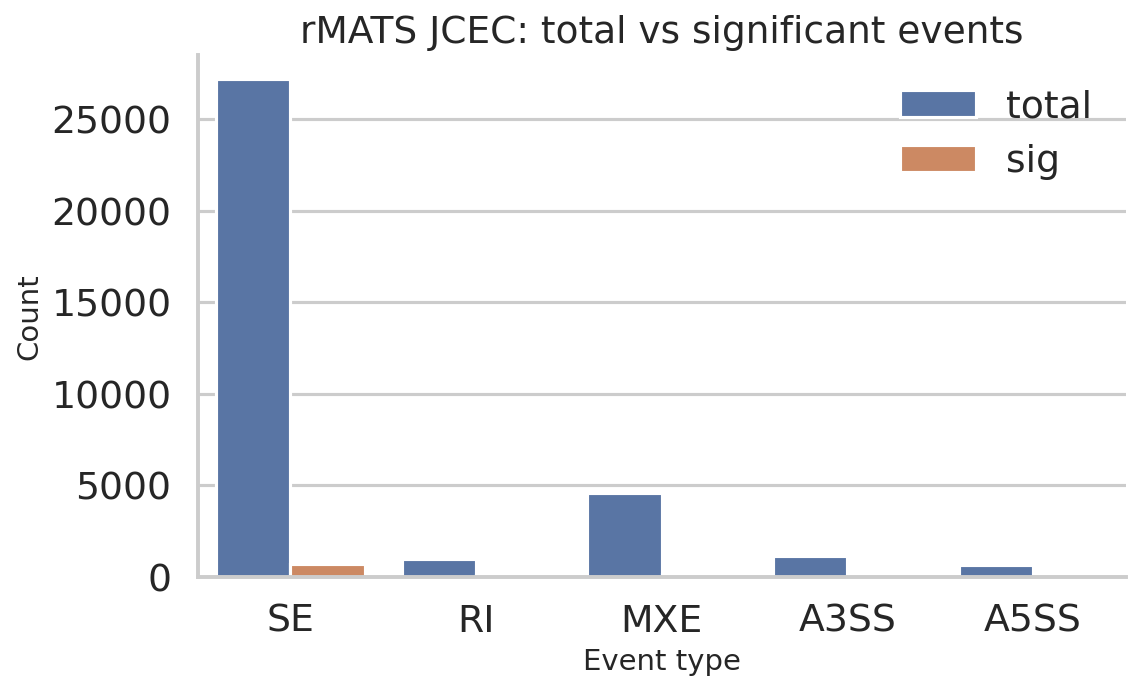

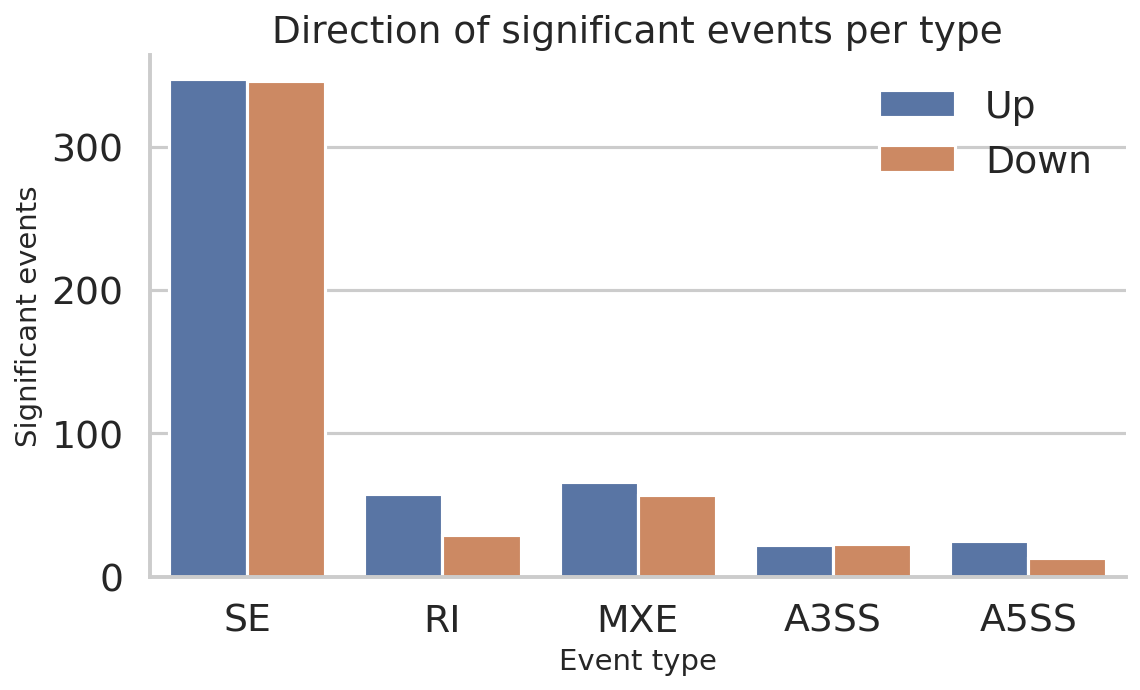

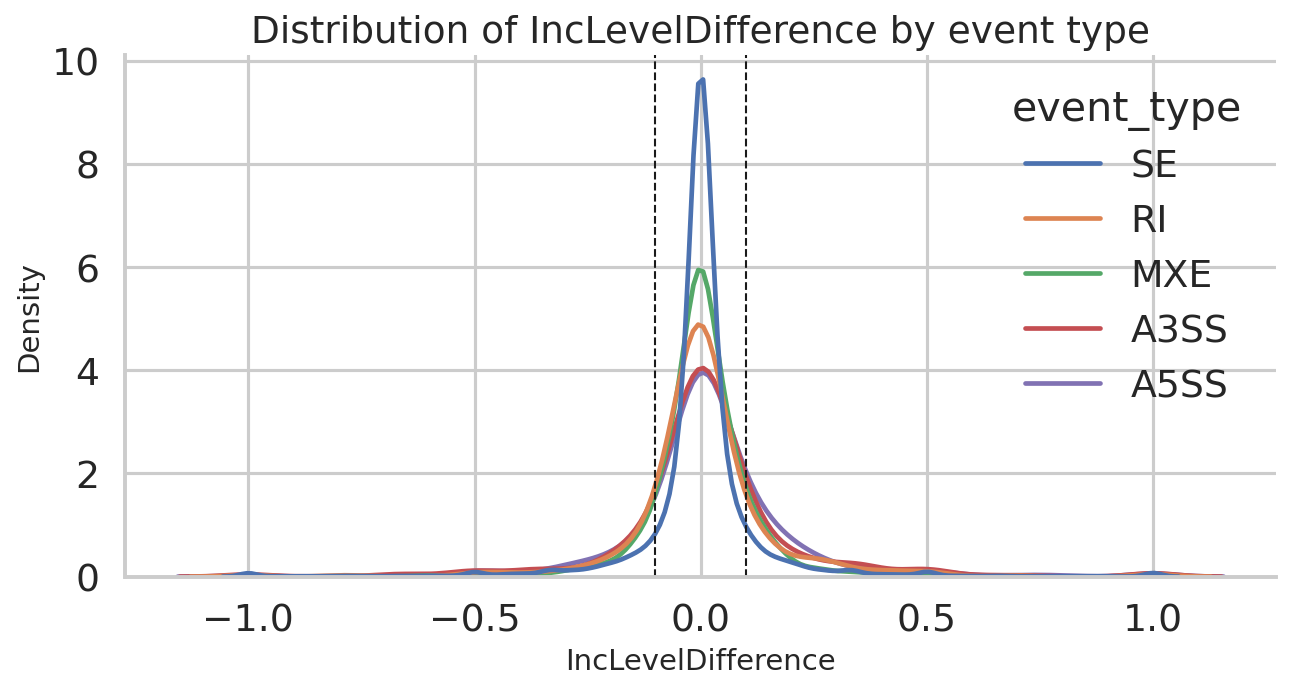

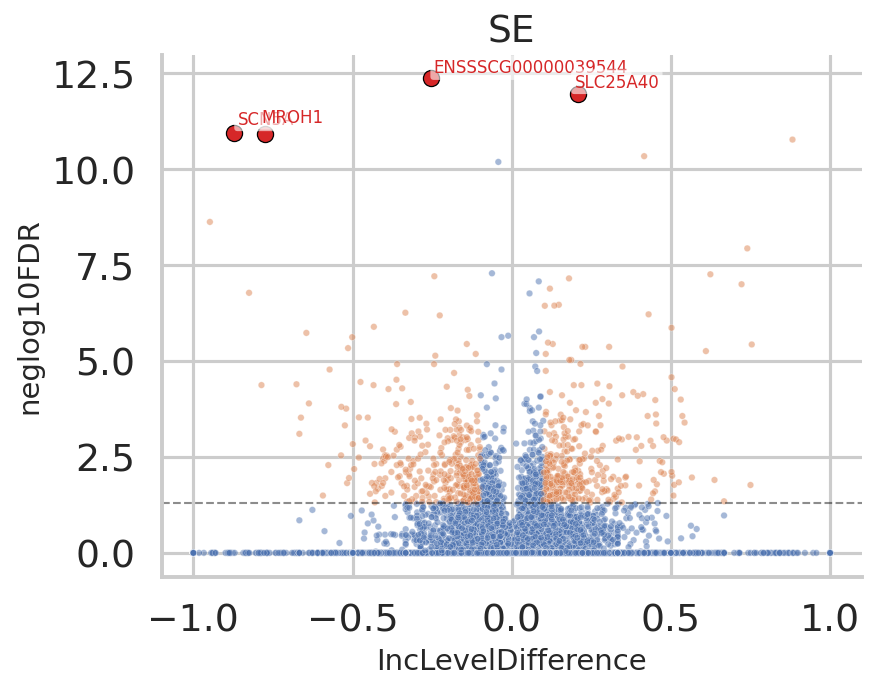

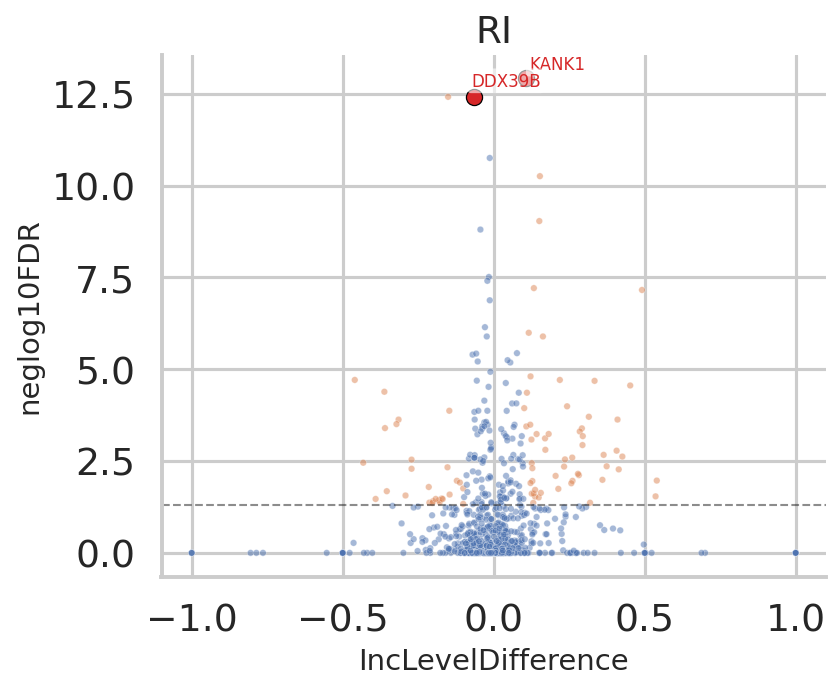

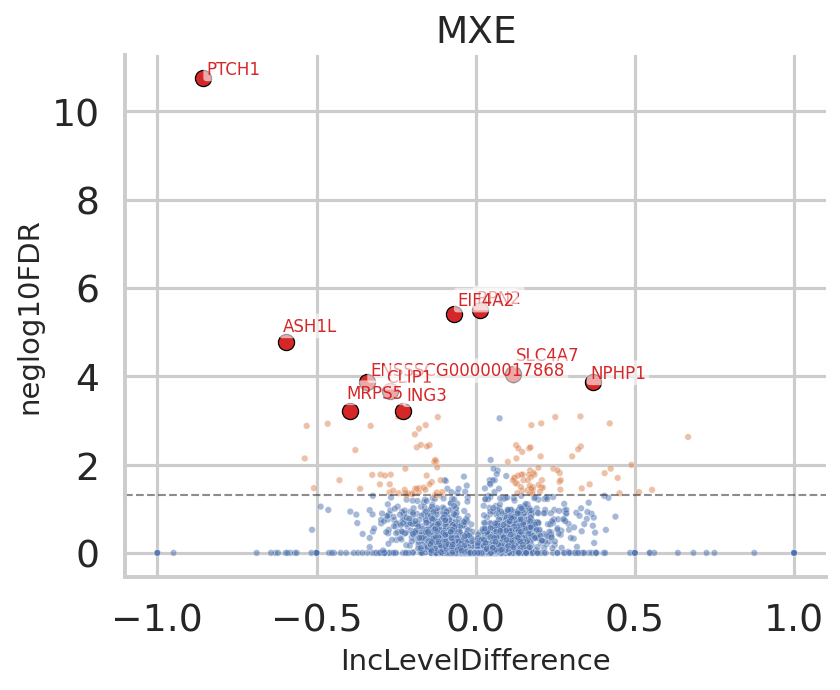

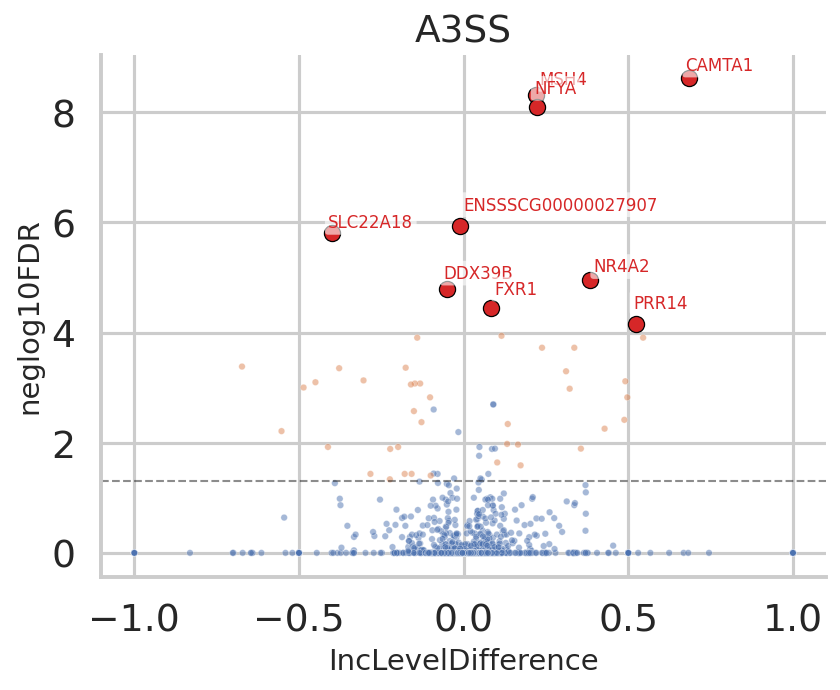

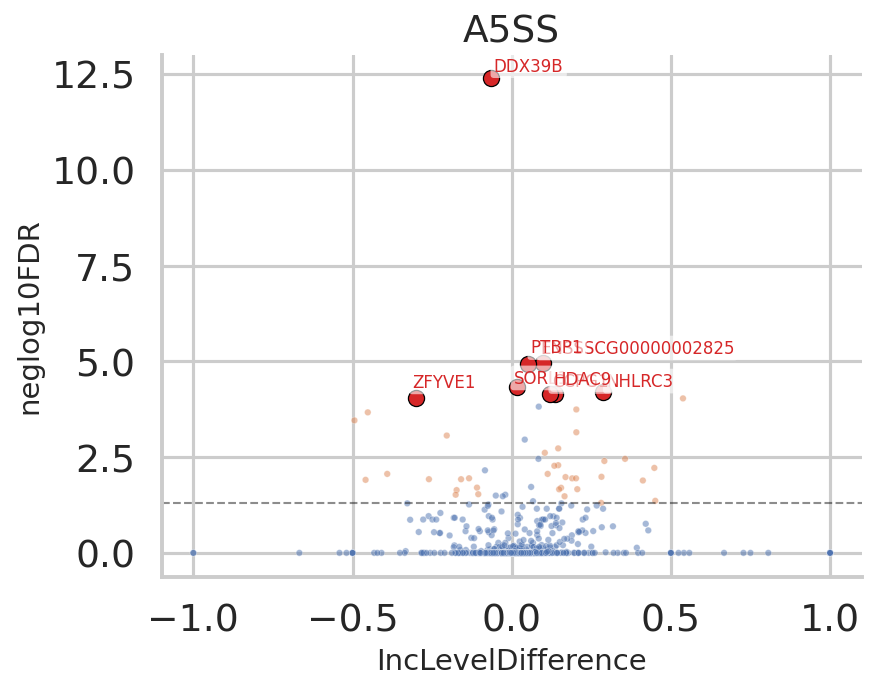

NameError: name 'export_significant' is not defined

In [20]:
flagged, combined, summary_df = run_all(
    output_dir=OUTPUT_DIR,
    events=EVENTS,
    fdr_thresh=FDR_THRESH,
    inc_diff_thresh=INC_DIFF_THRESH,
    export_dir=OUTPUT_DIR / 'significant'
)
summary_df
